## 对于一个聚类标签中的数据建图
### label=3 
```
[  3  16  17  18  19  20  21  39  40  41  42  43  44  65  66  67  68  89
  90 108 109 110 111 112 130 131 132 133 134]
```

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import warnings
import numpy as np
import glob
import os
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [5]:
### 构建器
class EdgeFeatureGraphBuilder:
    """
    构建带有丰富边特征的图
    每条边包含多个特征维度：距离、相关性、方向等
    """

    def __init__(self, base_path, location_file, correlation_matrices=None, files_pattern="dated_Turb*.csv", file_list=None):
        """
        初始化边特征图构建器
        
        Parameters:
        base_path: 文件路径
        location_file: 风机位置文件
        correlation_matrices: 多个相关性矩阵
        files_pattern: 风速数据文件模式，如 "dated_Turb*.csv" (可选)
        file_list: 风速数据文件列表 (可选)
        """
        # 加载位置数据
        self.location_df = pd.read_csv(os.path.join(base_path, location_file))
        self.coords = self.location_df[["x", "y"]].values
        self.num_nodes = len(self.coords)
        
        # 存储风速数据文件模式或列表
        self.base_path = base_path
        self.files_pattern = files_pattern
        if file_list is not None:
            self.file_list = [files_pattern.replace('*', str(file_name)) for file_name in file_list]
            self.file_index = np.array(file_list) - 1
            self.coords = self.coords[self.file_index]
            self.num_nodes = len(file_list)
            print(f"使用提供的 {len(file_list)} 个风速数据文件")
            print(file_list)
        else:
            self.file_index = np.arange(self.num_nodes)
        # 计算距离矩阵
        self.distance_matrix = squareform(pdist(self.coords, "euclidean"))
        
        # 存储相关性矩阵
        self.correlation_matrices = correlation_matrices
        print(f"初始化完成: {self.num_nodes} 个节点")
    
    def load_wind_speed_data(self, train_ratio=0.7, feature_col="Wspd"):
        """
        从CSV文件加载风速数据
        
        Parameters:
        train_ratio: 训练集比例
        feature_col: 特征列名
        
        Returns:
        numpy array: 风速数据矩阵 [num_turbines, timesteps]
        """
        if self.files_pattern is None:
            raise ValueError("未提供风速文件模式，请在初始化时设置 files_pattern")

        data_files = glob.glob(os.path.join(self.base_path, self.files_pattern))
        if len(data_files) == 0:
            raise ValueError(f"未找到匹配的风速数据文件: {self.files_pattern}")
        print(f"找到 {len(data_files)} 个风速数据文件")

        #过滤文件名存在与file_list中
        if self.file_list is not None:
            data_files = [f for f in data_files if os.path.basename(f) in self.file_list]
            print(f"过滤后剩余 {len(data_files)} 个风速数据文件")
        data_files.sort()

        # 检查文件数量与节点数量是否匹配
        if len(data_files) != self.num_nodes:
            print(f"警告: 风速文件数量 ({len(data_files)}) 与节点数量 ({self.num_nodes}) 不匹配")
            # 取较小值
            num_files = min(len(data_files), self.num_nodes)
            data_files = data_files[:num_files]
        else:
            num_files = len(data_files)
        
        # 读取第一个文件确定数据长度
        sample_df = pd.read_csv(data_files[0])
        total_timesteps = len(sample_df)
        train_split = int(train_ratio * total_timesteps)
        print(f"总时间步数: {total_timesteps}, 训练集时间步数: {train_split}")
        
        # 检查特征列是否存在
        if feature_col not in sample_df.columns:
            print(f"特征列 '{feature_col}' 不存在，可用列: {list(sample_df.columns)}")
            raise ValueError(f"特征列 '{feature_col}' 不存在")
        
        # 初始化数组
        wind_speeds = np.zeros((num_files, train_split))
        
        # 加载数据
        for i, file in enumerate(tqdm(data_files, desc="加载风速数据")):
            try:
                df = pd.read_csv(file)
                # 检查数据长度
                if len(df) != total_timesteps:
                    print(f"警告: 文件 {file} 的数据长度不一致")
                    min_length = min(len(df), train_split)
                    wind_speeds[i, :min_length] = df[feature_col].iloc[:min_length].values
                else:
                    wind_speeds[i, :] = df[feature_col].iloc[:train_split].values
                
                # 数据质量检查
                turbine_data = wind_speeds[i, :]
                nan_count = np.isnan(turbine_data).sum()
                zero_count = (turbine_data == 0).sum()
                valid_ratio = (len(turbine_data) - nan_count - zero_count) / len(turbine_data)
                
                if valid_ratio < 0.5:
                    print(f"警告: 风机 {i} 有效数据比例过低 ({valid_ratio:.2%})")
                
                # 处理缺失值
                if np.isnan(turbine_data).any():
                    if valid_ratio > 0.1:
                        mean_val = np.nanmean(turbine_data)
                        if not np.isnan(mean_val):
                            mask = np.isnan(turbine_data)
                            wind_speeds[i, mask] = mean_val
                        else:
                            global_mean = np.nanmean(wind_speeds)
                            wind_speeds[i, :] = global_mean 
            except Exception as e:
                print(f"读取文件 {file} 时出错: {e}")

        self.wind_speed_data = wind_speeds
        print(f"风速数据加载完成: {wind_speeds.shape}")
        
        return wind_speeds
    
    def compute_spatial_features(self):
        """计算空间相关的特征"""
        print("计算空间特征...")
        features = {}      

        # 1. 标准化距离 (0-1)
        print("1. 标准化距离 (0-1)")
        max_dist = np.max(self.distance_matrix)
        features['normalized_distance'] = self.distance_matrix / max_dist

        # 2. 高斯距离核
        print("2. 高斯距离核")
        sigma = np.mean(self.distance_matrix[self.distance_matrix > 0]) / 3
        features['gaussian_distance'] = np.exp(-(self.distance_matrix ** 2) / (2 * sigma ** 2))

        # 3. 相对方位角 (弧度)
        print("3. 计算相对方位角 (弧度) 及 sin cos")
        angles = np.zeros((self.num_nodes, self.num_nodes))
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    dx = self.coords[j, 0] - self.coords[i, 0]
                    dy = self.coords[j, 1] - self.coords[i, 1]
                    angles[i, j] = np.arctan2(dy, dx)
        features['bearing_angle'] = angles

        # 4. 方位角的sin和cos分量 (便于神经网络处理)
        features['bearing_sin'] = np.sin(angles)
        features['bearing_cos'] = np.cos(angles)
        
        return features
    
    def compute_correlation_features(self):
        """计算相关性相关的特征"""
        if self.correlation_matrices is None:
            print("未提供相关性矩阵，跳过相关性特征计算")
            return {}
        print("计算相关性特征...")
        features = {}
        
        # 1. 原始相关性
        print("1. 原始相关性")
        features['pearson_correlation'] = self.correlation_matrices[0].copy()
        features['pearson_correlation'] = features['pearson_correlation'][self.file_index][:, self.file_index]

        # 2. 差分相关性
        print("2. 差分相关性")
        features['pearson_diff_correlation'] = self.correlation_matrices[1].copy()
        features['pearson_diff_correlation'] = features['pearson_diff_correlation'][self.file_index][:, self.file_index]

        # 3. 方向相关性
        print("3. 方向相关性")
        features['direction_correlation'] = self.correlation_matrices[2].copy()
        features['direction_correlation'] = features['direction_correlation'][self.file_index][:, self.file_index]

        # 4. 加权相关性
        print("4. 加权相关性")
        features['weighted_correlation'] = features['pearson_correlation'] * 0.2 + features['pearson_diff_correlation']*0.4 + features['direction_correlation']*0.4

        return features
    
    def compute_statistical_features(self):
        """计算统计相关的特征"""
        if self.wind_speed_data is None:
            print("未提供风速数据，跳过统计特征计算")
            return {}
        print("计算统计特征...")
        features = {}
        
        # 计算每对风机的统计特征
        lag_correlation = np.zeros((self.num_nodes, self.num_nodes))
        variance_ratio = np.zeros((self.num_nodes, self.num_nodes))
        mean_diff = np.zeros((self.num_nodes, self.num_nodes))
        
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    data_i = self.wind_speed_data[i, :]
                    data_j = self.wind_speed_data[j, :]
                    
                    lag_cor = 0
                    # 延迟相关 (滞后1)
                    if np.std(data_i) > 0 and np.std(data_j) > 0:
                        lag_cor += np.corrcoef(data_i[:-1], data_j[1:])[0, 1]
                    # 延迟相关 (滞后2)
                    if np.std(data_i) > 0 and np.std(data_j) > 0:
                        lag_cor += np.corrcoef(data_i[:-2], data_j[2:])[0, 1]
                    lag_correlation[i, j] = lag_cor/2

                    # 方差比
                    var_i, var_j = np.var(data_i), np.var(data_j)
                    if var_j > 0:
                        variance_ratio[i, j] = var_i / var_j
                    
                    # 均值差
                    mean_diff[i, j] = np.mean(data_i) - np.mean(data_j)

        # 1. 滞后相关
        print("1. 滞后相关")
        features['lag_correlation'] = lag_correlation
        # 2. 方差比
        print("2. 方差比")
        features['variance_ratio'] = variance_ratio
        # 3. 均值差
        print("3. 均值差")
        features['mean_difference'] = mean_diff
        
        return features
    
    def build_edge_features(self, feature_types=['spatial', 'correlation', 'statistical']):
        """
        构建边特征矩阵
        
        Parameters:
        feature_types: 要包含的特征类型列表
        
        Returns:
        dict: 包含所有特征的字典
        """
        all_features = {}
        
        if 'spatial' in feature_types:
            spatial_features = self.compute_spatial_features()
            all_features.update(spatial_features)
        
        if 'correlation' in feature_types:
            correlation_features = self.compute_correlation_features()
            all_features.update(correlation_features)
        
        if 'statistical' in feature_types:
            statistical_features = self.compute_statistical_features()
            all_features.update(statistical_features)
        
        self.edge_features = all_features
        return all_features
    
    def create_edge_feature_tensor(self, adjacency_matrix=None, normalize_features=True):
        """
        创建用于GNN的边特征张量
        
        Parameters:
        adjacency_matrix: 邻接矩阵，定义哪些边存在
        normalize_features: 是否标准化特征
        
        Returns:
        edge_index: [2, num_edges] 边索引
        edge_attr: [num_edges, num_features] 边特征
        feature_names: 特征名称列表
        """
        if not hasattr(self, 'edge_features'):
            raise ValueError("请先调用 build_edge_features() 构建边特征")
        
        # 如果没有提供邻接矩阵，使用全连接图
        if adjacency_matrix is None:
            adjacency_matrix = np.ones((self.num_nodes, self.num_nodes)) - np.eye(self.num_nodes)
        
        # 找到所有存在的边
        edge_indices = np.where(adjacency_matrix > 0)
        edge_index = np.stack([edge_indices[0], edge_indices[1]], axis=0)
        num_edges = edge_index.shape[1]
        
        # 收集所有特征
        feature_names = list(self.edge_features.keys())
        num_features = len(feature_names)
        
        # 创建边特征矩阵
        edge_attr = np.zeros((num_edges, num_features))
        
        for feat_idx, feature_name in enumerate(feature_names):
            feature_matrix = self.edge_features[feature_name]
            # 提取对应边的特征值
            edge_attr[:, feat_idx] = feature_matrix[edge_indices[0], edge_indices[1]]
        
        # 标准化特征
        if normalize_features:
            scaler = StandardScaler()
            edge_attr = scaler.fit_transform(edge_attr)
            
            # 保存scaler用于后续使用
            self.feature_scaler = scaler
        
        print(f"边特征张量构建完成:")
        print(f"  边数量: {num_edges}")
        print(f"  特征维度: {num_features}")
        print(f"  特征名称: {feature_names}")
        
        return edge_index, edge_attr, feature_names
    
    def visualize_edge_features(self, feature_names=None, save_path="edge_features_analysis.png"):
        """可视化边特征分布"""
        if not hasattr(self, 'edge_features'):
            raise ValueError("请先调用 build_edge_features() 构建边特征")
        
        if feature_names is None:
            feature_names = list(self.edge_features.keys())[:12]  # 最多显示9个特征
        
        n_features = len(feature_names)
        n_cols = 4
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
        
        for i, feature_name in enumerate(feature_names):
            feature_matrix = self.edge_features[feature_name]
            
            # 只考虑非对角线元素
            mask = ~np.eye(self.num_nodes, dtype=bool)
            feature_values = feature_matrix[mask]
            
            # 移除无效值
            feature_values = feature_values[np.isfinite(feature_values)]
            
            if len(feature_values) > 0:
                axes[i].hist(feature_values, bins=50, alpha=0.7, edgecolor='black')
                axes[i].set_title(f'{feature_name}\n均值: {np.mean(feature_values):.3f}')
                axes[i].set_xlabel('特征值')
                axes[i].set_ylabel('频数')
                axes[i].grid(True, alpha=0.3)
        
        # 隐藏多余的子图
        for i in range(n_features, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"特征分布图已保存为 {save_path}")
    
    def create_graph_with_features(self, graph_type='knn', k=5, threshold=0.3):
        """
        创建带有边特征的图
        
        Parameters:
        graph_type: 'knn', 'threshold', 'full'
        k: KNN的k值
        threshold: 阈值图的阈值
        
        Returns:
        NetworkX图对象，包含边特征
        """
        if not hasattr(self, 'edge_features'):
            raise ValueError("请先调用 build_edge_features() 构建边特征")
        
        # 创建邻接矩阵
        if graph_type == 'knn':
            adj_matrix = kneighbors_graph(
                self.coords, k, mode='connectivity', include_self=False
            ).toarray()
            # 确保对称性
            adj_matrix = (adj_matrix + adj_matrix.T > 0).astype(int)
        elif graph_type == 'threshold':
            if self.correlation_matrix is not None:
                adj_matrix = (np.abs(self.correlation_matrix) > threshold).astype(int)
            else:
                # 使用距离阈值
                dist_threshold = np.percentile(self.distance_matrix[self.distance_matrix > 0], 20)
                adj_matrix = (self.distance_matrix < dist_threshold).astype(int)
                np.fill_diagonal(adj_matrix, 0)  
        elif graph_type == 'full':
            adj_matrix = np.ones((self.num_nodes, self.num_nodes)) - np.eye(self.num_nodes)
        
        # 创建NetworkX图
        G = nx.from_numpy_array(adj_matrix)
        
        # 为图添加位置信息
        pos = dict(zip(range(self.num_nodes), self.coords))
        nx.set_node_attributes(G, pos, 'pos')
        
        # 为边添加特征
        for u, v in G.edges():
            edge_features = {}
            for feature_name, feature_matrix in self.edge_features.items():
                edge_features[feature_name] = feature_matrix[u, v]
            G[u][v].update(edge_features)
        
        return G, adj_matrix
    
    def save_edge_features_for_pytorch_geometric(self, adj_matrix, save_prefix="graph_data"):
        """
        保存为PyTorch Geometric格式
        """
        edge_index, edge_attr, feature_names = self.create_edge_feature_tensor(adj_matrix, False)
        
        # 保存数据
        np.save(f"{save_prefix}_edge_index.npy", edge_index)
        np.save(f"{save_prefix}_edge_attr.npy", edge_attr)
        np.save(f"{save_prefix}_node_coords.npy", self.coords)
        np.save(f"{save_prefix}_node_index.npy", self.file_index)
        
        # 保存特征名称
        with open(f"{save_prefix}_feature_names.txt", "w") as f:
            for name in feature_names:
                f.write(f"{name}\n")
        
        print(f"PyTorch Geometric数据已保存:")
        print(f"  {save_prefix}_edge_index.npy - 边索引 [{edge_index.shape}]")
        print(f"  {save_prefix}_edge_attr.npy - 边特征 [{edge_attr.shape}]")
        print(f"  {save_prefix}_node_coords.npy - 节点坐标 [{self.coords.shape}]")
        print(f"  {save_prefix}_feature_names.txt - 特征名称")
        
        return edge_index, edge_attr, feature_names


1. 加载相关性矩阵
(134, 134)
(134, 134)
(134, 134)
使用提供的 29 个风速数据文件
[3, 16, 17, 18, 19, 20, 21, 39, 40, 41, 42, 43, 44, 65, 66, 67, 68, 89, 90, 108, 109, 110, 111, 112, 130, 131, 132, 133, 134]
初始化完成: 29 个节点
2. 从CSV文件加载风速数据...
找到 134 个风速数据文件
过滤后剩余 29 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696


加载风速数据: 100%|██████████| 29/29 [00:02<00:00, 11.78it/s]


风速数据加载完成: (29, 24696)
3. 构建边特征
计算空间特征...
1. 标准化距离 (0-1)
2. 高斯距离核
3. 计算相对方位角 (弧度) 及 sin cos
计算相关性特征...
1. 原始相关性
2. 差分相关性
3. 方向相关性
4. 加权相关性
计算统计特征...
1. 滞后相关
2. 方差比
3. 均值差
   构建了 12 种边特征

4. 可视化特征分布...


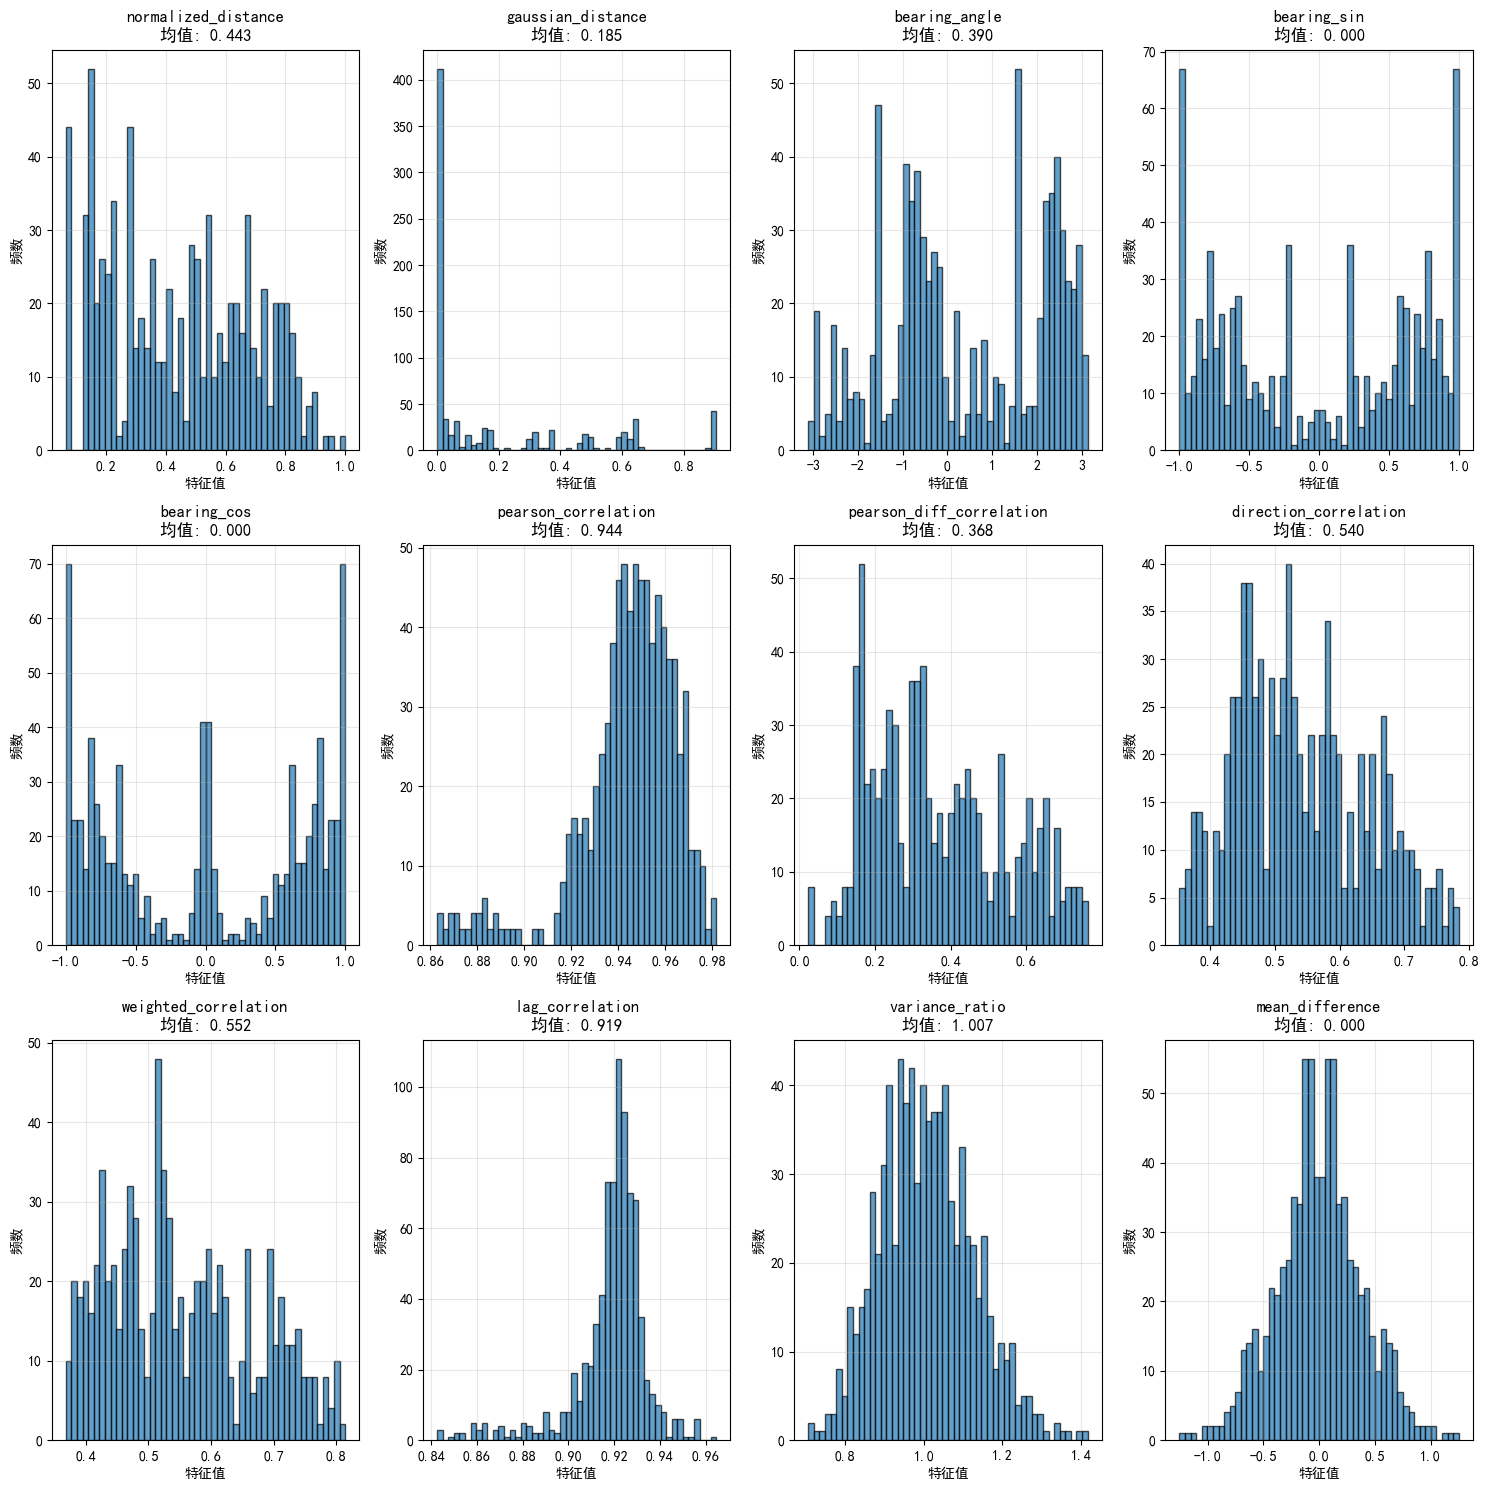

特征分布图已保存为 particial_edge_features_distribution.png

6. 创建PyTorch Geometric数据...
边特征张量构建完成:
  边数量: 812
  特征维度: 12
  特征名称: ['normalized_distance', 'gaussian_distance', 'bearing_angle', 'bearing_sin', 'bearing_cos', 'pearson_correlation', 'pearson_diff_correlation', 'direction_correlation', 'weighted_correlation', 'lag_correlation', 'variance_ratio', 'mean_difference']
PyTorch Geometric数据已保存:
  particial_edge_feature_knn_edge_index.npy - 边索引 [(2, 812)]
  particial_edge_feature_knn_edge_attr.npy - 边特征 [(812, 12)]
  particial_edge_feature_knn_node_coords.npy - 节点坐标 [(29, 2)]
  particial_edge_feature_knn_feature_names.txt - 特征名称

=== 构建完成 ===
图统计:
  节点数量: 29
 边数量: 812
 特征形状: (812, 12)
  边特征维度: 12
  特征列表: ['normalized_distance', 'gaussian_distance', 'bearing_angle', 'bearing_sin', 'bearing_cos', 'pearson_correlation', 'pearson_diff_correlation', 'direction_correlation', 'weighted_correlation', 'lag_correlation', 'variance_ratio', 'mean_difference']


In [6]:
file_list = [3, 16, 17, 18, 19, 20, 21, 39, 40, 41, 42, 43, 44, 65, 66, 67, 68, 89, 90, 108, 109, 110, 111, 112, 130, 131, 132, 133, 134]
graph_type='knn'
k=5

pearson_correlation_matrix_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/2_cluster/wind_speed_correlation_matrices.npz"
pearson_diff_correlation_matrix_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/2_cluster/wind_speed_diff_correlation_matrices.npz"
pearson_direction_correlation_matrix_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/2_cluster/weighted_correlation_matrix.npz"

pearson_correlation_matrix = np.load(pearson_correlation_matrix_path)['original']
pearson_diff_correlation_matrix = np.load(pearson_diff_correlation_matrix_path)['original']
pearson_direction_correlation_matrix = np.load(pearson_direction_correlation_matrix_path)['original']

print("1. 加载相关性矩阵")
print(pearson_correlation_matrix.shape)
print(pearson_diff_correlation_matrix.shape)
print(pearson_direction_correlation_matrix.shape)

# 初始化构建器
builder = EdgeFeatureGraphBuilder(
    base_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/dataset/spatial_graph",
    location_file = "sdwpf_baidukddcup2022_turb_location.CSV", 
    correlation_matrices=[
        pearson_correlation_matrix,
        pearson_diff_correlation_matrix,
        pearson_direction_correlation_matrix
    ],
    file_list=file_list
)

# 加载风速数据
print("2. 从CSV文件加载风速数据...")
wind_speed_data = builder.load_wind_speed_data()

# 3. 构建边特征
print("3. 构建边特征")
feature_types = ['spatial']  # 空间特征始终包含
feature_types.append('correlation')
feature_types.append('statistical')

edge_features = builder.build_edge_features(feature_types)
print(f"   构建了 {len(edge_features)} 种边特征")

# 4. 可视化特征分布
print(f"\n4. 可视化特征分布...")
builder.visualize_edge_features(save_path=f"particial_edge_features_distribution.png")

# 5. 创建图
#print(f"\n5. 创建{graph_type}图...")
#G, adj_matrix = builder.create_graph_with_features(graph_type=graph_type, k=k)

# 6. 创建PyTorch Geometric格式数据
print(f"\n6. 创建PyTorch Geometric数据...")
edge_index, edge_attr, feature_names = builder.save_edge_features_for_pytorch_geometric(
    None, f"particial_edge_feature_{graph_type}"
)

print(f"\n=== 构建完成 ===")
print(f"图统计:")
print(f"  节点数量: {builder.num_nodes}")
print(f" 边数量: {edge_index.shape[1]}")
print(f" 特征形状: {edge_attr.shape}")
print(f"  边特征维度: {len(feature_names)}")
print(f"  特征列表: {feature_names}")